# 01 — Prozkoumání AirfRANS datasetu

**Cíl tohoto notebooku:** Stáhnout AirfRANS dataset, načíst první simulaci a podívat se na to,
co všechno obsahuje. Po dokončení budeš mít vizuální intuici o tom, co bude tvůj model později predikovat.

**Workflow:** Spouštěj buňky postupně přes `Shift+Enter`. Pokud něco selže, napiš Claudovi error a vyřeš to,
než půjdeš dál — pořadí buněk je důležité.

---

## 1. Ověření prostředí

Nejdřív zkontrolujeme že máme vše co potřebujeme.

In [3]:
import sys
import torch

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Python: 3.12.13
PyTorch: 2.12.1+cu126
CUDA available: True
GPU: NVIDIA GeForce GTX 1650
VRAM: 4.29 GB


## 2. Stažení AirfRANS datasetu

AirfRANS obsahuje **1000 ustálených 2D RANS simulací** kolem různých NACA airfoilů
při různých úhlech náběhu a rychlostech proudění. Stažení trvá ~5-10 minut (cca 2-3 GB).

**Spustíš jen jednou** — pokud už máš data stažená, buňka je přeskočí.

In [2]:
import os
import airfrans as af

DATA_ROOT = "../data"
DATASET_DIR = os.path.join(DATA_ROOT, "Dataset")

if not os.path.exists(DATASET_DIR):
    print("Stahuji AirfRANS dataset (~2-3 GB, potrva to chvili)...")
    af.dataset.download(root=DATA_ROOT, file_name="Dataset", unzip=True)
    print("Hotovo!")
else:
    print(f"Dataset uz existuje v {DATASET_DIR}, preskakuji stazeni.")

Stahuji AirfRANS dataset (~2-3 GB, potrva to chvili)...


Extracting Dataset.zip at ../data...
Hotovo!


## 3. Načtení dat

Dataset má několik "tasků" (jak rozdělit data na train/test):
- `full` — všech 1000 simulací jako trénink (na to se zaměříme my)
- `scarce` — málo trénovacích dat
- `reynolds` — split podle Reynoldsova čísla
- `aoa` — split podle úhlu náběhu

Vrátí nám list NumPy polí (každé pole = jedna simulace) a list jmen.

In [3]:
dataset_list, names = af.dataset.load(
    root=DATASET_DIR,
    task="full",
    train=True,
)

print(f"Pocet simulaci: {len(dataset_list)}")
print(f"Tvar prvni simulace: {dataset_list[0].shape}")
print(f"Prvni jmeno: {names[0]}")

Loading dataset (task: full, split: train): 100%|██████████| 800/800 [09:09<00:00,  1.46it/s]

Pocet simulaci: 800
Tvar prvni simulace: (181794, 12)
Prvni jmeno: airFoil2D_SST_36.622_11.319_3.941_5.424_1.0_16.283


## 4. Co je v jedné simulaci?

Každá simulace je 2D pole o tvaru `(N_bodu, 11)`, kde sloupce znamenají:

| Sloupec | Význam |
|---------|--------|
| 0, 1 | x, y souřadnice bodu meshe |
| 2 | normála x |
| 3 | normála y |
| 4, 5 | vstupní rychlost (inlet) x, y |
| 6 | distance function (vzdálenost od airfoilu, signed) |
| 7, 8 | rychlost u, v |
| 9 | tlak |
| 10 | turbulentní viskozita ν_t |

`N_bodu` je různé pro každou simulaci (typicky 100-200 tisíc bodů, hustší u airfoilu).

In [5]:
sim = dataset_list[0]
print(f"Tvar: {sim.shape}")
print(f"Pocet bodu meshe: {sim.shape[0]:,}")
print()
print("Statistiky jednotlivych sloupcu:")
print(f"  x:        [{sim[:,0].min():.2f}, {sim[:,0].max():.2f}]")
print(f"  y:        [{sim[:,1].min():.2f}, {sim[:,1].max():.2f}]")
print(f"  inlet:    ({sim[0,4]:.2f}, {sim[0,5]:.2f}) m/s")
print(f"  u:        [{sim[:,7].min():.2f}, {sim[:,7].max():.2f}] m/s")
print(f"  v:        [{sim[:,8].min():.2f}, {sim[:,8].max():.2f}] m/s")
print(f"  tlak:     [{sim[:,9].min():.2f}, {sim[:,9].max():.2f}] Pa")

Tvar: (181794, 12)
Pocet bodu meshe: 181,794

Statistiky jednotlivych sloupcu:
  x:        [-2.16, 4.23]
  y:        [-1.62, 1.61]
  inlet:    (3.28, 0.00) m/s
  u:        [-16.80, 65.92] m/s
  v:        [-6.22, 64.46] m/s
  tlak:     [-1943.72, 671.11] Pa


## 5. Dekódování názvu simulace

Názvy simulací obsahují metadata, např. `airFoil2D_SST_57.872_7.314_5.454_3.799_13.179`:

| Token | Význam |
|-------|--------|
| `SST` | turbulentní model (k-omega SST) |
| `57.872` | vstupní rychlost [m/s] |
| `7.314` | úhel náběhu [°] |
| `5.454` | NACA parametr 1 (max camber × 100) |
| `3.799` | NACA parametr 2 (camber position × 10) |
| `13.179` | NACA parametr 3 (thickness × 100) |

In [6]:
def decode_name(name):
    """Vrati slovnik s metadaty simulace."""
    parts = name.split("_")
    # Format: airFoil2D_SST_<vel>_<aoa>_<m>_<p>_<t>
    return {
        "inlet_velocity": float(parts[2]),
        "angle_of_attack": float(parts[3]),
        "naca_m": float(parts[4]),
        "naca_p": float(parts[5]),
        "naca_t": float(parts[6]),
    }


meta = decode_name(names[0])
print(f"Jmeno: {names[0]}")
for k, v in meta.items():
    print(f"  {k}: {v}")

Jmeno: airFoil2D_SST_36.622_11.319_3.941_5.424_1.0_16.283
  inlet_velocity: 36.622
  angle_of_attack: 11.319
  naca_m: 3.941
  naca_p: 5.424
  naca_t: 1.0


## 6. Vizualizace tlakového pole

Teď to nejdůležitější — **podívej se na proudění**. Vykreslíme tlakové pole jako scatter plot,
kde každý bod meshe = jeden bod scatter plotu, barva = hodnota tlaku.

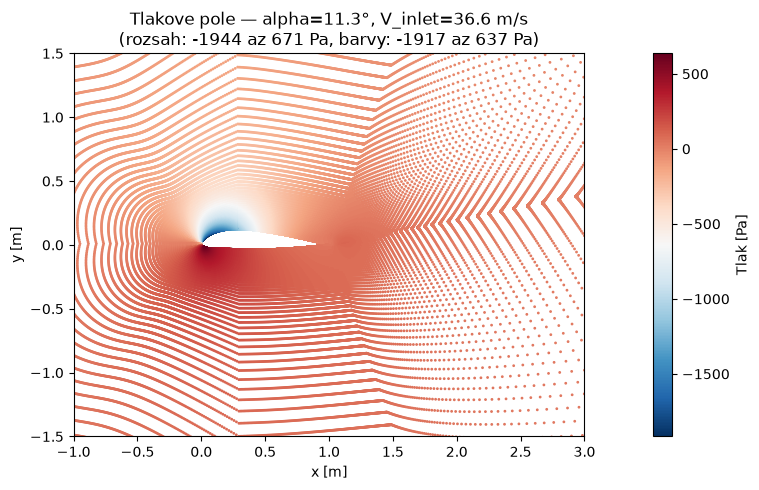

In [9]:
import matplotlib.pyplot as plt
import numpy as np

sim = dataset_list[0]
meta = decode_name(names[0])

x = sim[:, 0]
y = sim[:, 1]
pressure = sim[:, 9]

# Pouzij percentily misto hard-coded rozsahu
vmin, vmax = np.percentile(pressure, [1, 99])

fig, ax = plt.subplots(figsize=(14, 5))
sc = ax.scatter(x, y, c=pressure, cmap="RdBu_r", s=1, vmin=vmin, vmax=vmax)
ax.set_aspect("equal")
ax.set_xlim(-1, 3)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(
    f"Tlakove pole — alpha={meta['angle_of_attack']:.1f}°, "
    f"V_inlet={meta['inlet_velocity']:.1f} m/s\n"
    f"(rozsah: {pressure.min():.0f} az {pressure.max():.0f} Pa, "
    f"barvy: {vmin:.0f} az {vmax:.0f} Pa)"
)
plt.colorbar(sc, label="Tlak [Pa]")
plt.tight_layout()
plt.show()

In [8]:
# Zjistime co je v kterem sloupci a v jakem rozsahu
sim = dataset_list[0]
print(f"Tvar: {sim.shape}\n")
print(f"{'sloupec':<10}{'min':>15}{'max':>15}{'mean':>15}")
print("-" * 55)
for i in range(sim.shape[1]):
    col = sim[:, i]
    print(f"{i:<10}{col.min():>15.4f}{col.max():>15.4f}{col.mean():>15.4f}")

Tvar: (181794, 12)

sloupec               min            max           mean
-------------------------------------------------------
0                 -2.1591         4.2267         0.5005
1                 -1.6180         1.6139         0.0253
2                 35.9097        35.9097        35.9097
3                  7.1878         7.1878         7.1878
4                  0.0000         3.5416         0.2307
5                 -0.9977         1.0000         0.0018
6                 -1.0000         1.0000         0.0001
7                -16.8034        65.9227        21.9929
8                 -6.2226        64.4579        12.3762
9              -1943.7250       671.1070      -236.3876
10                 0.0000         0.0268         0.0012
11                 0.0000         1.0000         0.0056


**Co bys měl vidět:** Hladká RdBu (červeno-modrá) heatmapa s **modrou oblastí
(podtlak) na horní straně airfoilu a červenou (přetlak) na spodní** — to je přesně to,
co generuje vztlak. Pokud vidíš jen šum nebo prázdný plot, něco je špatně — napiš Claudovi.

## 7. Vizualizace rychlostního pole

Stejně tak rychlost. Vykreslíme magnitude rychlosti `|U| = sqrt(u² + v²)`.

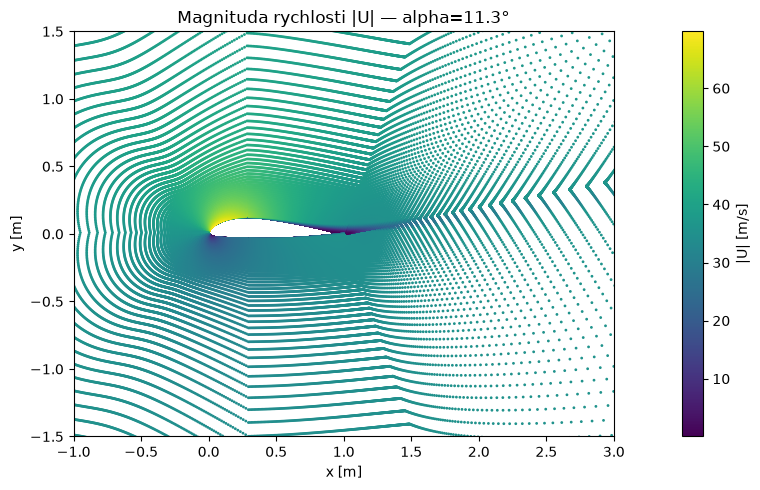

In [10]:
u, v = sim[:, 7], sim[:, 8]
speed = np.sqrt(u**2 + v**2)
vmin, vmax = np.percentile(speed, [1, 99])  # ← pridej tohle

fig, ax = plt.subplots(figsize=(14, 5))
sc = ax.scatter(x, y, c=speed, cmap="viridis", s=1, vmin=vmin, vmax=vmax)  # ← vmin/vmax
ax.set_aspect("equal")
ax.set_xlim(-1, 3); ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title(f"Magnituda rychlosti |U| — alpha={meta['angle_of_attack']:.1f}°")
plt.colorbar(sc, label="|U| [m/s]")
plt.tight_layout(); plt.show()

**Co bys měl vidět:** Žlutá/světle zelená oblast nad horní stranou airfoilu
(zrychlené proudění = nižší tlak) a tmavší úplav (wake) za odtokovou hranou.

## 8. Signed distance function (důležitá pro vstup modelu)

Sloupec 6 obsahuje **signed distance function (SDF)** — vzdálenost od povrchu airfoilu.
Záporné hodnoty = uvnitř airfoilu, kladné = ve fluidu. Tohle je super reprezentace
geometrie pro neuronku — místo binární masky dáš model gradient vzdálenosti.

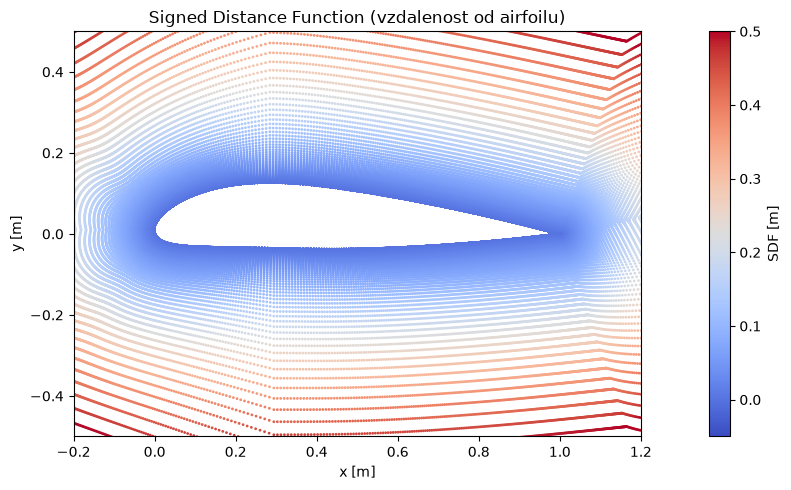

In [11]:
sdf = sim[:, 4] 

fig, ax = plt.subplots(figsize=(14, 5))
sc = ax.scatter(x, y, c=sdf, cmap="coolwarm", s=1, vmin=-0.05, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Signed Distance Function (vzdalenost od airfoilu)")
plt.colorbar(sc, label="SDF [m]")
plt.tight_layout()
plt.show()

## 9. Porovnání různých úhlů náběhu

Najdeme tři simulace s různými úhly náběhu (nízký, střední, vysoký) a vykreslíme tlak vedle sebe.
Tohle ti dá pocit jak moc se proudění mění s úhlem.

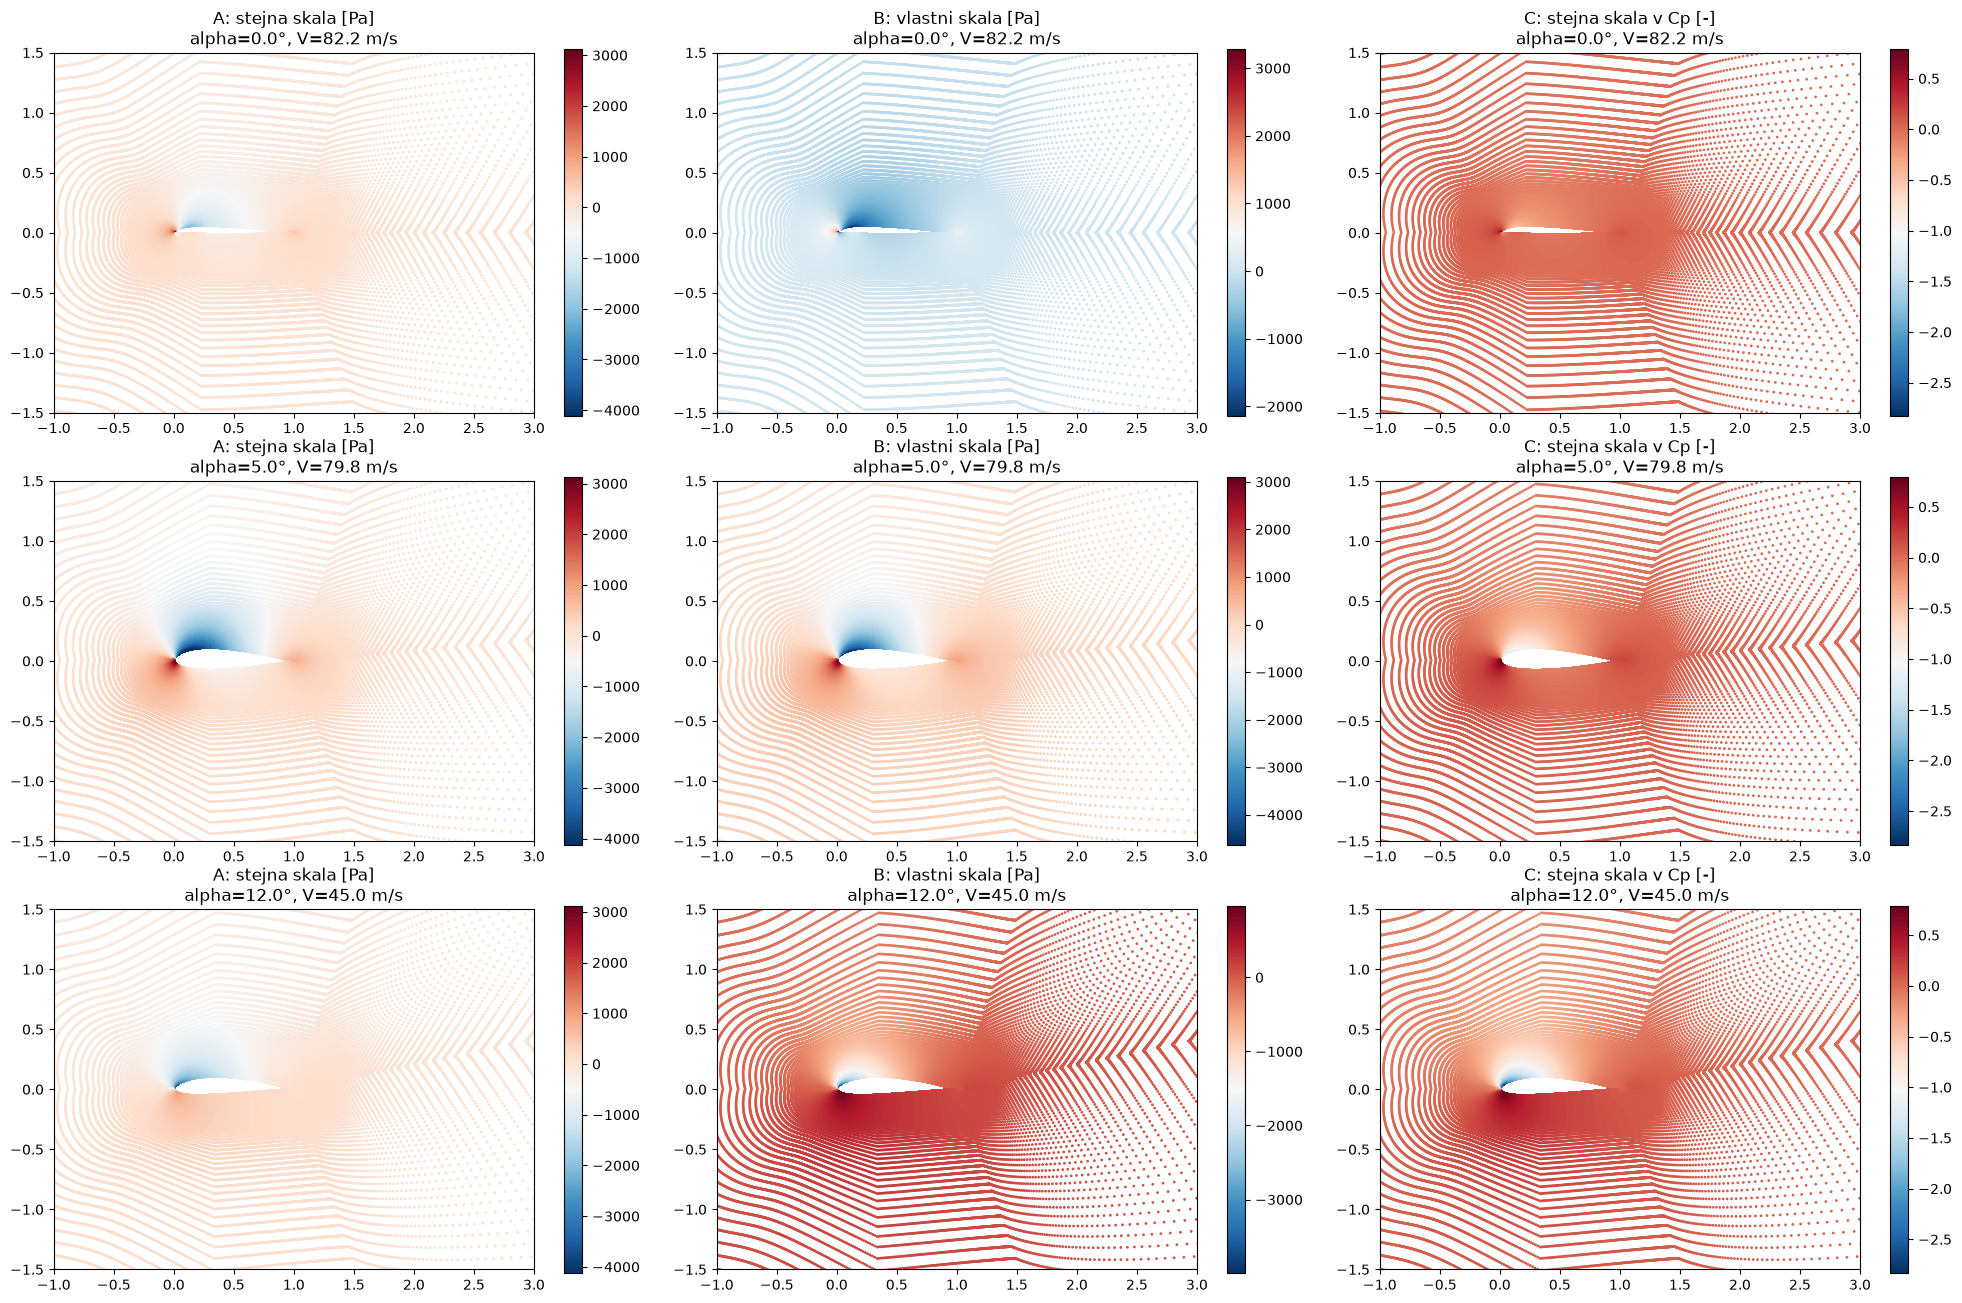

In [15]:
import matplotlib.pyplot as plt
import numpy as np

aoas = np.array([decode_name(n)["angle_of_attack"] for n in names])
indices = [
    np.argmin(np.abs(aoas - 0)),
    np.argmin(np.abs(aoas - 5)),
    np.argmin(np.abs(aoas - 12)),
]

# Pripravime si data + Cp pro vsechny tri
data = []
for idx in indices:
    s = dataset_list[idx]
    m = decode_name(names[idx])
    p = s[:, 9]
    # Cp = (p - p_inf) / (0.5 * rho * V^2). Predpokladame ze v dataset je p uz "p - p_inf"
    # (gauge pressure) a rho = 1.225 kg/m^3 (vzduch standardni atmosfera)
    rho = 1.225
    V = m["inlet_velocity"]
    cp = p / (0.5 * rho * V**2)
    data.append({"x": s[:,0], "y": s[:,1], "p": p, "cp": cp, "meta": m})

# 3 sloupce = 3 ruzne pristupy, 3 radky = 3 ruzne uhly
fig, axes = plt.subplots(3, 3, figsize=(20, 13))

# Sloupec 0: spolecna skala v Pa (co mas teď)
all_p = np.concatenate([d["p"] for d in data])
vmin_p, vmax_p = np.percentile(all_p, [1, 99])

# Sloupec 2: spolecna skala v Cp
all_cp = np.concatenate([d["cp"] for d in data])
vmin_cp, vmax_cp = np.percentile(all_cp, [1, 99])

for row, d in enumerate(data):
    m = d["meta"]
    title = f"alpha={m['angle_of_attack']:.1f}°, V={m['inlet_velocity']:.1f} m/s"

    # Sloupec 0: stejna skala v Pa (absolutni)
    ax = axes[row, 0]
    sc = ax.scatter(d["x"], d["y"], c=d["p"], cmap="RdBu_r", s=1, vmin=vmin_p, vmax=vmax_p)
    ax.set_aspect("equal"); ax.set_xlim(-1, 3); ax.set_ylim(-1.5, 1.5)
    ax.set_title(f"A: stejna skala [Pa]\n{title}")
    plt.colorbar(sc, ax=ax)

    # Sloupec 1: vlastni skala v Pa (kazdy si svoje)
    ax = axes[row, 1]
    vmin, vmax = np.percentile(d["p"], [1, 99])
    sc = ax.scatter(d["x"], d["y"], c=d["p"], cmap="RdBu_r", s=1, vmin=vmin, vmax=vmax)
    ax.set_aspect("equal"); ax.set_xlim(-1, 3); ax.set_ylim(-1.5, 1.5)
    ax.set_title(f"B: vlastni skala [Pa]\n{title}")
    plt.colorbar(sc, ax=ax)

    # Sloupec 2: stejna skala v Cp (bezrozmerne)
    ax = axes[row, 2]
    sc = ax.scatter(d["x"], d["y"], c=d["cp"], cmap="RdBu_r", s=1, vmin=vmin_cp, vmax=vmax_cp)
    ax.set_aspect("equal"); ax.set_xlim(-1, 3); ax.set_ylim(-1.5, 1.5)
    ax.set_title(f"C: stejna skala v Cp [-]\n{title}")
    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()

**Pozoruj:** S rostoucím úhlem náběhu se podtlaková zóna (modrá) nahoře zvětšuje
a intenzifikuje. To je přesně to, co generuje větší vztlak. Tohle je fyzika — a tvůj model
se přesně tuhle dynamiku bude muset naučit z dat.

## 10. Histogramy distribucí parametrů

Pochopení distribuce dat je klíčové pro vědomí kde model bude fungovat dobře
a kde bude extrapolovat (= out-of-distribution).

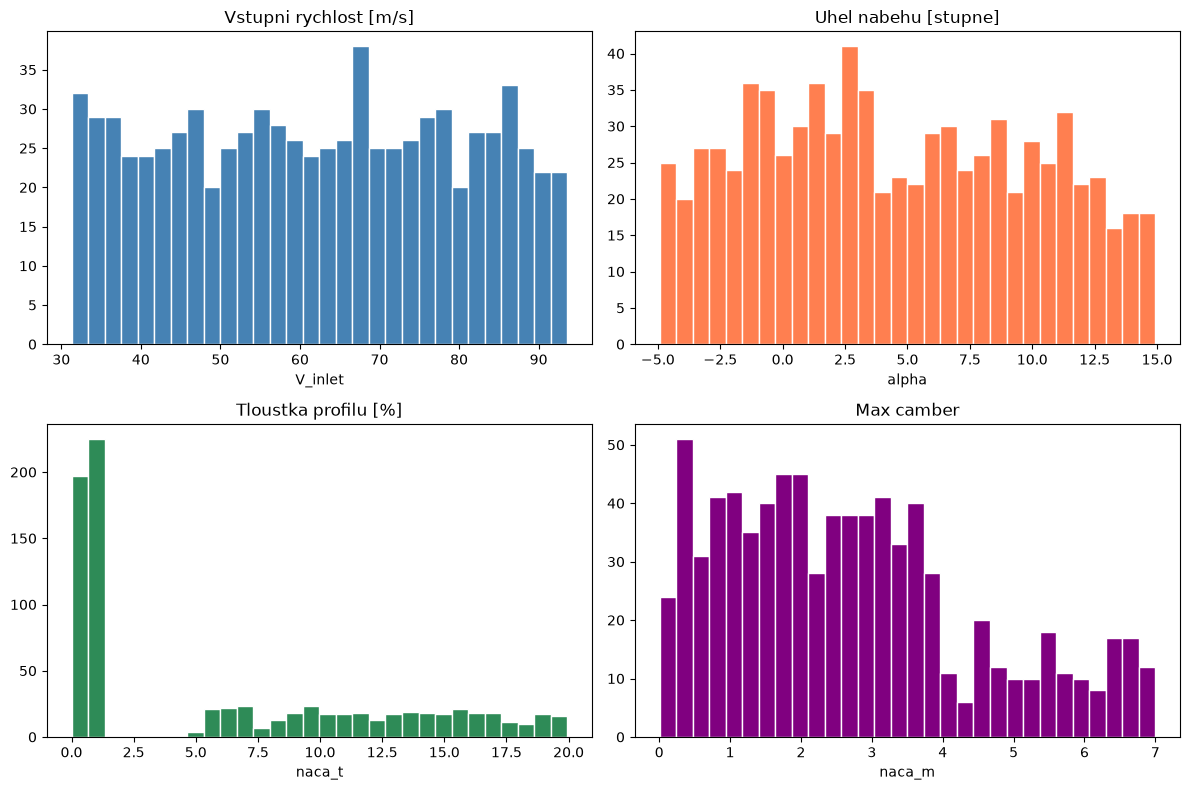


Range uhlu nabehu: [-4.9°, 14.9°]
Range rychlosti:    [31.3, 93.6] m/s
Range tloustky:     [0.0%, 19.9%]


In [13]:
velocities  = np.array([decode_name(n)["inlet_velocity"] for n in names])
aoas        = np.array([decode_name(n)["angle_of_attack"] for n in names])
thicknesses = np.array([decode_name(n)["naca_t"] for n in names])
cambers     = np.array([decode_name(n)["naca_m"] for n in names])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(velocities, bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Vstupni rychlost [m/s]")
axes[0, 0].set_xlabel("V_inlet")

axes[0, 1].hist(aoas, bins=30, color="coral", edgecolor="white")
axes[0, 1].set_title("Uhel nabehu [stupne]")
axes[0, 1].set_xlabel("alpha")

axes[1, 0].hist(thicknesses, bins=30, color="seagreen", edgecolor="white")
axes[1, 0].set_title("Tloustka profilu [%]")
axes[1, 0].set_xlabel("naca_t")

axes[1, 1].hist(cambers, bins=30, color="purple", edgecolor="white")
axes[1, 1].set_title("Max camber")
axes[1, 1].set_xlabel("naca_m")

plt.tight_layout()
plt.show()

print(f"\nRange uhlu nabehu: [{aoas.min():.1f}°, {aoas.max():.1f}°]")
print(f"Range rychlosti:    [{velocities.min():.1f}, {velocities.max():.1f}] m/s")
print(f"Range tloustky:     [{thicknesses.min():.1f}%, {thicknesses.max():.1f}%]")

**Klíčový insight:** Tahle distribuce **definuje hranice tvého modelu**.
Pokud bude AoA v datech jen do 15°, model nebude umět predikovat 25° (stall).
Pokud nejsou velmi tlusté profily, nebude umět tlustou kapku. Tohle je
základ celého OOD experimentu o kterém jsme se bavili (trojúhelník, ručně malovaný tvar).

## 11. Tip: hraj si!

Než půjdeš na notebook 02 (preprocessing na grid), zkus si pohrát:

- Změň index `dataset_list[0]` na jiné číslo a vykresli pár dalších simulací
- Najdi simulaci s **největším úhlem náběhu** — jak vypadá proudění?
- Vykresli `nu_t` (turbulentní viskozita, sloupec 10) — uvidíš kde je proudění turbulentní
- Spočítej **kolik simulací má AoA > 10°** — to budou těžké případy pro model

Až tě to omrzí (nebo budou všechny otázky zodpovězené), napiš Claudovi
**"hotovo, jdeme dál"** a pustíme se do notebook 02 — interpolace na 128×128 grid + PyTorch Dataset.